<center> <h2><b>2 Supervised Learning</b></h2> </center>

In [1]:
import importlib
import sys
sys.path.append("..")  # Ensure the parent directory is in the path

import visualization.data_exploration_plots
import data_preprocessing.data_preprocessing
import models.classic_ml.classic_ml_models
import models.lstm_rnn.lstm_rnn

# Reload the module to reflect changes
importlib.reload(visualization.data_exploration_plots)
importlib.reload(data_preprocessing.data_preprocessing)
importlib.reload(models.classic_ml.classic_ml_models)
importlib.reload(models.lstm_rnn.lstm_rnn)

from data_preprocessing.data_cleaning import *
from data_preprocessing.data_preprocessing import *
from models.classic_ml.classic_ml_models import *
from utils.data_loader import load_and_clean_data

from models.lstm_rnn.lstm_rnn import preprocess_for_lstm, build_lstm_model, build_bidirectional_lstm_model

import tensorflow as tf

from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
from keras.utils import set_random_seed
from keras.src.callbacks import EarlyStopping, ReduceLROnPlateau


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
set_random_seed(42)

# Prepare Data

In [2]:
x_paths = ['set-a.parquet', 'set-b.parquet', 'set-c.parquet']
y_paths = ['outcomes-a.parquet', 'outcomes-b.parquet', 'outcomes-c.parquet']

X_train, X_valid, X_test, y_train, y_valid, y_test = load_and_clean_data(x_paths, y_paths, clean_data)

In [3]:
X_train.head(3)

,recordid,time,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,132539,00:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,132539,01:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,35.6,NaN,NaN,60.0,NaN,NaN,NaN
2,132539,02:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,18.0,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN


## Q2.1 Classic Machine Learning Methods - Random Forest and Logistic Regression

### 2.1.1 Basic Feature engineering

In [4]:
X_train_mean, X_valid_mean, X_test_mean = prepare_data_basic_for_ML_classifier(X_train, X_valid, X_test, method="mean")

X_train_max, X_valid_max, X_test_max = prepare_data_basic_for_ML_classifier(X_train, X_valid, X_test, method="max")

X_train_last_measured, X_valid_last_measured, X_test_last_measured = prepare_data_basic_for_ML_classifier(X_train, X_valid, X_test, method="last")

Training and Evaluating LR Models: 100%|██████████| 3/3 [00:00<00:00,  6.42dataset/s]


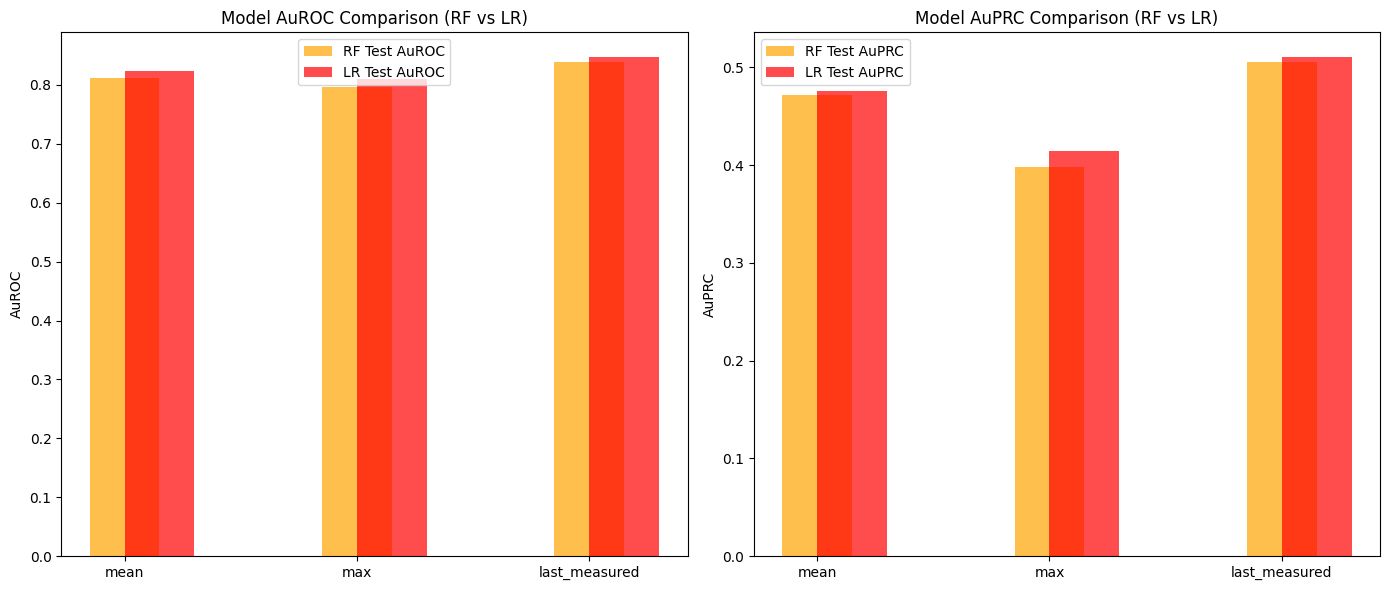

In [5]:
# Dictionary of X datasets (mean, max, last_measured)
X_train_dict = {
    'mean': X_train_mean,
    'max': X_train_max,
    'last_measured': X_train_last_measured
}

X_valid_dict = {
    'mean': X_valid_mean,
    'max': X_valid_max,
    'last_measured': X_valid_last_measured
}

X_test_dict = {
    'mean': X_test_mean,
    'max': X_test_max,
    'last_measured': X_test_last_measured
}

# Train and evaluate both models (Random Forest and Logistic Regression)
datasets = ['mean', 'max', 'last_measured']

# Random Forest Results
results_rf = train_and_evaluate_for_datasets(datasets, 'rf', X_train_dict, X_valid_dict, X_test_dict, y_train, y_valid, y_test)

# Logistic Regression Results
results_lr = train_and_evaluate_for_datasets(datasets, 'lr', X_train_dict, X_valid_dict, X_test_dict, y_train, y_valid, y_test)

# Plot the performance comparison for both models
plot_performance_comparison(results_rf, results_lr)

In [6]:
results_rf

{'mean': {'test_auroc': 0.8114680081590768, 'test_auprc': 0.472213128767732},
 'max': {'test_auroc': 0.7967163469359664, 'test_auprc': 0.39817303643108126},
 'last_measured': {'test_auroc': 0.839259676389984,
  'test_auprc': 0.5059278062922332}}

In [7]:
results_lr

{'mean': {'test_auroc': 0.8235712229855713, 'test_auprc': 0.4759260547048854},
 'max': {'test_auroc': 0.8109181464379123, 'test_auprc': 0.41487040613174964},
 'last_measured': {'test_auroc': 0.8470258162205453,
  'test_auprc': 0.510391616395691}}

### 2.1.2 More advanced feature engineering

In [8]:
X_train_advanced, X_valid_advanced, X_test_advanced = prepare_data_advanced_for_ML_classifier(X_train, X_valid, X_test)

In [9]:
results_rf_advanced = train_and_evaluate_model('rf', X_train_advanced, X_valid_advanced, X_test_advanced, y_train, y_valid, y_test)

In [10]:
results_lr_advanced = train_and_evaluate_model('lr', X_train_advanced, X_valid_advanced, X_test_advanced, y_train, y_valid, y_test)

In [11]:
results_rf_advanced

{'validation': {'auroc': 0.8394881233789684, 'auprc': 0.5120266102484299},
 'test': {'auroc': 0.8413520041045663, 'auprc': 0.5195693365135322}}

In [12]:
results_lr_advanced

{'validation': {'auroc': 0.8478615721133326, 'auprc': 0.5216534753013997},
 'test': {'auroc': 0.8474758168462414, 'auprc': 0.5048003895932193}}

## Q2.2 Recurrent Neural Networks
### Simple LSTM model

In [13]:
X_train_lstm, X_valid_lstm, X_test_lstm = preprocess_for_lstm(X_train, X_valid, X_test)
lstm_model = build_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))

history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_valid_lstm, y_valid),
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]
)
y_test_pred = lstm_model.predict(X_test_lstm).ravel()  # Flatten the predictions

test_auroc = roc_auc_score(y_test, y_test_pred)  # Use predicted probabilities for AUROC
test_auprc = average_precision_score(y_test, y_test_pred)  # Use predicted probabilities for AUPRC
print(f"Classical RNN Performance:")
print(f"AUROC: {test_auroc:.4f}")
print(f"AUPRC: {test_auprc:.4f}")

Epoch 1/30


C:\Users\afons\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7689 - loss: 2.1739 - precision: 0.2552 - recall: 0.2411 - val_accuracy: 0.8625 - val_loss: 1.1415 - val_precision: 0.5363 - val_recall: 0.2342 - learning_rate: 5.0000e-04
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8657 - loss: 1.0063 - precision: 0.6230 - recall: 0.2367 - val_accuracy: 0.8655 - val_loss: 0.6824 - val_precision: 0.5605 - val_recall: 0.2447 - learning_rate: 5.0000e-04
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8716 - loss: 0.6323 - precision: 0.6801 - recall: 0.2543 - val_accuracy: 0.8660 - val_loss: 0.5049 - val_precision: 0.5645 - val_recall: 0.2465 - learning_rate: 5.0000e-04
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8759 - loss: 0.4837 - precision: 0.6958 - recall: 0.2879 - val_accuracy: 0.8673 - val_loss: 0.4390 - val_precision: 0.5714 - val_recall: 0.2606 - learning_rate: 5.0000e-04
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - 

### Bidirectional LSTM model

In [14]:
# Build the bidirectional LSTM model
bidirectional_lstm_model = build_bidirectional_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))

# Train the bidirectional LSTM model
history_bidirectional = bidirectional_lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_valid_lstm, y_valid),
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]
)

# Evaluate the model on the test set
y_test_pred_bidirectional = bidirectional_lstm_model.predict(X_test_lstm).ravel()

# Calculate AUROC and AUPRC
test_auroc_bidirectional = roc_auc_score(y_test, y_test_pred_bidirectional)
test_auprc_bidirectional = average_precision_score(y_test, y_test_pred_bidirectional)

print(f"Bidirectional LSTM Test Performance:")
print(f"AUROC: {test_auroc_bidirectional:.4f}")
print(f"AUPRC: {test_auprc_bidirectional:.4f}")

Epoch 1/30


C:\Users\afons\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.7838 - loss: 4.9292 - precision_1: 0.3015 - recall_1: 0.2833 - val_accuracy: 0.8615 - val_loss: 2.2255 - val_precision_1: 0.5407 - val_recall_1: 0.1637 - learning_rate: 5.0000e-04
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8575 - loss: 1.8429 - precision_1: 0.5694 - recall_1: 0.1669 - val_accuracy: 0.8662 - val_loss: 0.9899 - val_precision_1: 0.5922 - val_recall_1: 0.1866 - learning_rate: 5.0000e-04
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8661 - loss: 0.8729 - precision_1: 0.6494 - recall_1: 0.2175 - val_accuracy: 0.8645 - val_loss: 0.5968 - val_precision_1: 0.5508 - val_recall_1: 0.2482 - learning_rate: 5.0000e-04
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8698 - loss: 0.5597 - precision_1: 0.6555 - recall_1: 0.2622 - val_accuracy: 0.8712 - val_loss: 0.4667 - val_precision_1: 0.6305 - val_recall_1: 0.2254 - learning_rate: 5.0000e-04
Epoch 5/30
125/125 ━━━━

## Q2.3a: Transformers

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import math
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
def preprocess_data_for_transformer(df):
    # Make a copy to avoid modifying the original DataFrame
    df_processed = df.copy()
    
    # Identify feature columns (exclude recordid, time, and ICUType)
    exclude_cols = ['recordid', 'time', 'ICUType']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    # Group by patient (recordid) since we want to forward fill within each patient's time series
    grouped = df_processed.groupby('recordid')
    
    # Forward fill within each patient's time series
    df_processed[feature_cols] = grouped[feature_cols].ffill()
    
    # For any remaining NAs (e.g., first measurements that were NA), fill with median
    # Calculate medians from training data only to avoid data leakage
    train_medians = df_processed[feature_cols].median()
    df_processed[feature_cols] = df_processed[feature_cols].fillna(train_medians)
    
    return df_processed

# Apply preprocessing to each dataset
df_train_processed = preprocess_data_for_transformer(X_train)
df_val_processed = preprocess_data_for_transformer(X_valid)
df_test_processed = preprocess_data_for_transformer(X_test)

In [ ]:
# Data Preparation

# 1. Process the DataFrame into proper 3D array (patients × timesteps × features)
def prepare_data_for_transformer(df, outcomes):
    # Get unique patient IDs
    patient_ids = df['recordid'].unique()
    
    # Initialize empty array (num_patients, 49 timesteps, 41 features)
    X = np.zeros((len(patient_ids), 49, 41))
    y = np.zeros(len(patient_ids))
    
    # Sort by recordid and time to ensure correct ordering
    df = df.sort_values(['recordid', 'time'])
    
    for i, pid in enumerate(patient_ids):
        # Get all measurements for this patient
        patient_data = df[df['recordid'] == pid]
        
        # Extract features (drop recordid and time columns)
        patient_features = patient_data.drop(['recordid', 'time'], axis=1).values
        
        # Ensure we have exactly 49 timesteps
        if len(patient_features) != 49:
            raise ValueError(f"Patient {pid} has {len(patient_features)} timesteps (expected 49)")
        
        X[i] = patient_features
        y[i] = outcomes.loc[outcomes['recordid'] == pid, 'in_hospital_death'].values[0]
    
    return X, y

# Prepare the data
X_train, y_train = prepare_data_for_transformer(df_train_processed, y_train)
X_val, y_val = prepare_data_for_transformer(df_val_processed, y_valid)
X_test, y_test = prepare_data_for_transformer(df_test_processed, y_test)

# Normalize the data (fit only on training set)
scaler = RobustScaler()
# Reshape to (num_samples*49, 41) for scaling
X_train_reshaped = X_train.reshape(-1, 41)
scaler.fit(X_train_reshaped)

# Scale all sets
X_train = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_val_reshaped = X_val.reshape(-1, 41)
X_val = scaler.transform(X_val_reshaped).reshape(X_val.shape)
X_test_reshaped = X_test.reshape(-1, 41)
X_test = scaler.transform(X_test_reshaped).reshape(X_test.shape)

In [ ]:
# PyTorch Dataset and Transformer Implementation
class ICUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = ICUDataset(X_train, y_train)
val_dataset = ICUDataset(X_val, y_val)
test_dataset = ICUDataset(X_test, y_test)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=49):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class ICUTransformer(nn.Module):
    def __init__(self, input_dim=41, d_model=64, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1):
        super().__init__()
        
        # Input embedding
        self.input_proj = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x shape: (batch_size, seq_len=49, input_dim=41)
        x = self.input_proj(x)  # (batch_size, 49, d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        
        # Use mean pooling across time dimension
        x = x.mean(dim=1)  # (batch_size, d_model)
        return self.classifier(x)

In [ ]:
# Training and Evaluation
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    best_val_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        val_loss, val_auroc, val_auprc = evaluate_model(model, val_loader)
        
        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train Loss: {train_loss/len(train_loader):.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val AUROC: {val_auroc:.4f} | Val AUPRC: {val_auprc:.4f}")
        
    #     # Save best model
    #     if val_loss < best_val_loss:
    #         best_val_loss = val_loss
    #         torch.save(model.state_dict(), 'best_transformer_model.pth')
    
    # # Load best model
    # model.load_state_dict(torch.load('best_transformer_model.pth'))
    return model

def evaluate_model(model, loader):
    model.eval()
    criterion = nn.BCELoss()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    auroc = roc_auc_score(all_labels, all_preds)
    auprc = average_precision_score(all_labels, all_preds)
    
    return total_loss/len(loader), auroc, auprc

# Initialize and train model
model = ICUTransformer()
model = train_model(model, train_loader, val_loader, epochs=10)

# Final evaluation on test set
test_loss, test_auroc, test_auprc = evaluate_model(model, test_loader)
print(f"\nTest Performance:")
print(f"Loss: {test_loss:.4f} | AUROC: {test_auroc:.4f} | AUPRC: {test_auprc:.4f}")

## Q2.3b: Tokenizing Time-Series Data and Transformers

In [ ]:
# =============================================================================
# 1. Grouping by Patient and Converting Time Strings to Numeric Hours
# =============================================================================

def parse_time_str(time_str):
    """Parses a time string (e.g. '00:00', '01:00', ..., '48:00') into a float hour."""
    hour_str, _ = time_str.split(":")
    hour = int(hour_str)
    return hour

def group_and_sort(df):
    """
    Groups the dataframe by recordid and sorts each group by time (converted to hour).
    Returns a dictionary mapping recordid -> DataFrame for that patient.
    """
    # Convert the time column to numeric hours
    df = df.copy()
    df['hour'] = df['time'].apply(parse_time_str)
    grouped = dict(tuple(df.sort_values("hour").groupby("recordid")))
    return grouped

patients_a = group_and_sort(X_train)
patients_b = group_and_sort(X_valid)
patients_c = group_and_sort(X_test)

In [ ]:
# =============================================================================
# 2. Define Feature Columns and Global Scaling (Fitted on Training Data)
# =============================================================================

# We want to use all features except "recordid", "time", and "ICUType".
# (You may adjust this list based on your project instructions.)
skip_cols = {"recordid", "time", "ICUType", "hour"}
feature_cols = [col for col in X_train.columns if col not in skip_cols]

# Collect all non-missing values from training patients for scaling.
all_vals = []
for pid, df in patients_a.items():
    for col in feature_cols:
        vals = df[col].dropna().values.astype(float)
        if vals.size:
            all_vals.append(vals)
if all_vals:
    all_vals = np.concatenate(all_vals)
    global_min = np.min(all_vals)
    global_max = np.max(all_vals)
else:
    global_min, global_max = 0, 1  # fallback in case of no values

def scale_value(v):
    """Scale a value v to [0, 1] based on training min/max."""
    if np.isnan(v):
        return np.nan
    return (v - global_min) / (global_max - global_min)

In [ ]:
# =============================================================================
# 3. Tokenization Function
# =============================================================================

def tokenize_patient(df):
    """
    Given a patient's DataFrame (one row per time step) returns a list of tokens.
    Each token is a triplet: (t, z, v)
      - t: scaled time in [0,1] computed as hour / max_hour (assume max_hour from data, e.g., 48)
      - z: index corresponding to a feature (index in feature_cols, plus offset for static features)
      - v: scaled value (using the global scaler)
    We iterate over each time step (row) and for each feature in feature_cols.
    """
    tokens = []
    max_hour = df['hour'].max() if df['hour'].max() > 0 else 48  # assume 48 if not available
    for _, row in df.iterrows():
        # Scale time: note that time is available in the 'hour' column.
        scaled_time = row['hour'] / max_hour
        for idx, col in enumerate(feature_cols):
            v = row[col]
            if pd.notnull(v):
                scaled_val = scale_value(float(v))
                # Token is [t, z, v]. Here, z is simply the index (0 to len(feature_cols)-1).
                tokens.append([scaled_time, idx, scaled_val])
    return tokens

# Process all patients (for each split)
tokenized_a = {pid: tokenize_patient(df) for pid, df in patients_a.items()}
tokenized_b = {pid: tokenize_patient(df) for pid, df in patients_b.items()}
tokenized_c = {pid: tokenize_patient(df) for pid, df in patients_c.items()}

# For labels, create a dictionary mapping recordid -> in_hospital_death.
def label_dict(y_df):
    return dict(zip(y_df['recordid'], y_df['in_hospital_death']))

labels_a = label_dict(y_train)
labels_b = label_dict(y_valid)
labels_c = label_dict(y_test)

In [ ]:
# =============================================================================
# 4. PyTorch Dataset and Collate Function
# =============================================================================

class ICUTokenDataset(Dataset):
    def __init__(self, tokenized_dict, labels_dict):
        """
        tokenized_dict: dict mapping recordid -> list of tokens (each token is [t, z, v])
        labels_dict: dict mapping recordid -> label
        """
        self.records = list(tokenized_dict.keys())
        self.tokenized_dict = tokenized_dict
        self.labels_dict = labels_dict

    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        recordid = self.records[idx]
        tokens = np.array(self.tokenized_dict[recordid], dtype=np.float32)  # shape: (L, 3)
        label = np.array([self.labels_dict[recordid]], dtype=np.float32)
        return tokens, label

def collate_fn(batch):
    """
    Pads variable-length token sequences.
    Returns:
      - tokens_padded: [B, L_max, 3]
      - labels: [B, 1]
      - lengths: list of original lengths
    """
    tokens_list, labels_list = zip(*batch)
    lengths = [len(tokens) for tokens in tokens_list]
    max_len = max(lengths)
    padded_tokens = []
    for tokens in tokens_list:
        pad_len = max_len - len(tokens)
        if pad_len > 0:
            pad = np.full((pad_len, 3), 0.0, dtype=np.float32)
            tokens = np.concatenate([tokens, pad], axis=0)
        padded_tokens.append(tokens)
    tokens_padded = np.stack(padded_tokens, axis=0)
    labels = np.stack(labels_list, axis=0)
    return torch.tensor(tokens_padded), torch.tensor(labels), lengths

# Create datasets for each split.
dataset_a = ICUTokenDataset(tokenized_a, labels_a)
dataset_b = ICUTokenDataset(tokenized_b, labels_b)
dataset_c = ICUTokenDataset(tokenized_c, labels_c)

# For demonstration, we create a DataLoader for the training set.
dataloader_a = DataLoader(dataset_a, batch_size=16, shuffle=True, collate_fn=collate_fn)
dataloader_b = DataLoader(dataset_b, batch_size=16, shuffle=False, collate_fn=collate_fn)
dataloader_c = DataLoader(dataset_c, batch_size=16, shuffle=False, collate_fn=collate_fn)


In [ ]:
# =============================================================================
# 5. Define the Transformer Model (Tokenized Approach)
# =============================================================================

class TokenizedTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, num_variables=len(feature_cols)):
        super(TokenizedTransformer, self).__init__()
        # Project time (scalar) to d_model dimensions.
        self.time_proj = nn.Linear(1, d_model)
        # Learn an embedding for each variable index.
        self.var_embedding = nn.Embedding(num_variables, d_model)
        # Project the measurement value (scalar) to d_model dimensions.
        self.value_proj = nn.Linear(1, d_model)
        
        # Use a Transformer Encoder. Setting batch_first=True simplifies shape handling.
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        # Final classification head.
        self.fc = nn.Linear(d_model, 1)
    
    def forward(self, tokens, lengths):
        """
        tokens: [B, L, 3] where last dimension = (t, z, v)
        lengths: list of actual sequence lengths (for masking)
        """
        # Split token features:
        t = tokens[:, :, 0:1]              # [B, L, 1]
        z = tokens[:, :, 1].long()           # [B, L] for embedding lookup
        v = tokens[:, :, 2:3]              # [B, L, 1]
        
        # Compute embeddings.
        t_embed = self.time_proj(t)         # [B, L, d_model]
        z_embed = self.var_embedding(z)       # [B, L, d_model]
        v_embed = self.value_proj(v)         # [B, L, d_model]
        
        # Fuse the embeddings (simple additive fusion).
        token_embed = t_embed + z_embed + v_embed  # [B, L, d_model]
        
        # Process through the Transformer Encoder.
        transformer_out = self.transformer_encoder(token_embed)  # [B, L, d_model]
        
        # Create a mask: assume padded tokens sum to zero.
        mask = (tokens.abs().sum(dim=2) != 0).unsqueeze(-1).float()  # [B, L, 1]
        masked_out = transformer_out * mask
        lengths_tensor = torch.tensor(lengths, dtype=torch.float32, device=tokens.device).unsqueeze(1)
        pooled = masked_out.sum(dim=1) / lengths_tensor  # mean pooling
        
        out = self.fc(pooled)
        return torch.sigmoid(out)

In [ ]:
# =============================================================================
# 6. Training Setup and Loop
# =============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TokenizedTransformer(d_model=64, nhead=4, num_layers=2, num_variables=len(feature_cols))
model.to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 20

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for tokens, labels_batch, lengths in dataloader_a:
        tokens = tokens.to(device)  # [B, L, 3]
        labels_batch = labels_batch.to(device)  # [B, 1]
        optimizer.zero_grad()
        outputs = model(tokens, lengths)  # [B, 1]
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * tokens.size(0)
    epoch_loss /= len(dataset_a)
    
    # Validation evaluation.
    model.eval()
    all_val_outputs = []
    all_val_labels = []
    with torch.no_grad():
        for tokens_val, labels_val, lengths_val in dataloader_b:
            tokens_val = tokens_val.to(device)
            labels_val = labels_val.to(device)
            outputs_val = model(tokens_val, lengths_val)
            all_val_outputs.append(outputs_val.cpu().numpy())
            all_val_labels.append(labels_val.cpu().numpy())
    all_val_outputs = np.concatenate(all_val_outputs, axis=0).ravel()  # flatten to 1D
    all_val_labels = np.concatenate(all_val_labels, axis=0).ravel()
    
    # Compute AuROC and AuPRC.
    try:
        auroc = roc_auc_score(all_val_labels, all_val_outputs)
    except ValueError:
        auroc = float('nan')  # if only one class is present in y_true
    auprc = average_precision_score(all_val_labels, all_val_outputs)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Val AuROC: {auroc:.4f} - Val AuPRC: {auprc:.4f}")
    model.train()

In [ ]:
# =============================================================================
# 7. Evaluation
# =============================================================================

model.eval()
all_test_outputs = []
all_test_labels = []
with torch.no_grad():
    for tokens_test, labels_test, lengths_test in dataloader_c:
        tokens_test = tokens_test.to(device)
        labels_test = labels_test.to(device)
        outputs_test = model(tokens_test, lengths_test)
        all_test_outputs.append(outputs_test.cpu().numpy())
        all_test_labels.append(labels_test.cpu().numpy())
all_test_outputs = np.concatenate(all_test_outputs, axis=0).ravel()
all_test_labels = np.concatenate(all_test_labels, axis=0).ravel()

try:
    test_auroc = roc_auc_score(all_test_labels, all_test_outputs)
except ValueError:
    test_auroc = float('nan')
test_auprc = average_precision_score(all_test_labels, all_test_outputs)

print(f"Test Set Results - AuROC: {test_auroc:.4f} - AuPRC: {test_auprc:.4f}")